<img src="./Imagenes/logo_UTN.svg" align="right" width="150" />

#### Teoría de los Circuitos II

# Trabajo Semanal 7
#### Alumno: Lucas Gallero
#### Profesor: Mariano Llamedo Soria
#### Ayudante de TPs: David Moharos
----

# Enunciado:

### 1) Sea la función inmitancia:

$$F(s)=\frac{s^4+4s^2+3}{s(s^2+2)}$$


Se pide hallar la topología circuital y los valores de los componentes:

a) Síntesis de $Z(s)$ mediante el método de Foster en su versión serie.

b) Síntesis de $Y(s)$ mediante el método de Foster en su versión derivación.

c) Síntesis de $Z(s)$ mediante el método de Cauer, remoción en infinito.

d) Síntesis de $Z(s)$ mediante el método de Cauer, remoción en DC.

Simular $Z(s)$ en LTspice, observando los cambios de fase y la ley de variación (pendiente) de la impedancia del dipolo.

### 2) Esquematice el mapa de remociones mediante el método gráfico y halle el valor de los componentes sabiendo que satisface la función admitancia propuesta:

$$Y(s)=\frac{s^5+18s^3+48s}{6s^4+42s^2+48}$$

<div align="center">
    <img src="./Imagenes/Enunciado2.png" alt="Topología propuesta para el ejercicio 2" width="400" />
</div>

En todos los casos, verificar los resultados obtenidos mediante:

- Simulación simbólica en Python utilizando el toolbox de PyTC2.
- Simulación circuital en LTspice.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Math, Image
from io import BytesIO
from schemdraw import Drawing
import schemdraw
import pytc2.dibujar as dibujos_pytc2
from pytc2.general import s, print_latex, print_subtitle, a_equal_b_latex_s
from pytc2.sintesis_dipolo import foster, cauer_LC
from pytc2.remociones import remover_polo_dc, remover_polo_jw
from pytc2.dibujar import (
    dibujar_foster_serie,
    dibujar_cauer_LC,
    dibujar_puerto_entrada,
    dibujar_funcion_exc_abajo,
    dibujar_elemento_derivacion,
    dibujar_espacio_derivacion,
    dibujar_tanque_derivacion,
)

In [2]:
%matplotlib inline
sp.init_printing()
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

In [3]:
# Los circuitos se muestran como PNG para que el visor los renderice completos.
schemdraw.use('matplotlib')
schemdraw.config(color='black', bgcolor='white', fontsize=14)

def mostrar_circuito(d):
    figura = d.draw(show=False, canvas='matplotlib').getfig()
    imagen = BytesIO()
    figura.savefig(imagen, format='png', dpi=160, bbox_inches='tight',
                   pad_inches=0.15, facecolor='white', transparent=False)
    ancho = min(900, round(figura.get_figwidth()*85))
    plt.close(figura)
    display(Image(data=imagen.getvalue(), format="png", width=ancho))

# Las funciones de PyTC2 muestran una imagen explícita del circuito.
dibujos_pytc2.display = mostrar_circuito

def dibujar_foster_derivacion_lc(k0, koo, ki, y_exc):
    # Primitivas de PyTC2 para las tres ramas de una red Foster LC.
    # Evita que algunas versiones dibujen la rama LC como una rama RC.
    d = Drawing(unit=4, canvas='matplotlib')
    d = dibujar_puerto_entrada(d, voltage_lbl=('+', '$V$', '-'), current_lbl='$I$')
    d = dibujar_funcion_exc_abajo(d, 'Y', y_exc, hacia_salida=True, k_gap_width=0.5)
    hay_rama = False
    if not k0.is_zero:
        d = dibujar_elemento_derivacion(d, 'L', 1/k0)
        hay_rama = True
    if not koo.is_zero:
        if hay_rama:
            dibujar_espacio_derivacion(d)
        d = dibujar_elemento_derivacion(d, 'C', koo)
        hay_rama = True
    for termino in ki:
        if hay_rama:
            dibujar_espacio_derivacion(d)
        d = dibujar_tanque_derivacion(d, inductor_label=termino[1],
                                      capacitor_label=1/termino[0])
        hay_rama = True
    mostrar_circuito(d)

---
# <ins>Resolución</ins>


## <ins>1. Síntesis de la función inmitancia</ins>

$$F(s)=\frac{s^4+4s^2+3}{s(s^2+2)}
=\frac{(s^2+1)(s^2+3)}{s(s^2+2)}$$

La función tiene polos en $s=0$, $s=\pm j\sqrt{2}$ y en infinito, y ceros en $s=\pm j$ y $s=\pm j\sqrt{3}$. En el semieje $j\omega$ se intercalan:

$$0\;(P)<1\;(C)<\sqrt{2}\;(P)<\sqrt{3}\;(C)<\infty\;(P).$$

Para a) se toma $Z(s)=F(s)$ y para b) se toma $Y(s)=F(s)$. Son dos realizaciones duales de la misma expresión de inmitancia.

In [4]:
F = (s**4 + 4*s**2 + 3) / (s*(s**2 + 2))
print_latex(a_equal_b_latex_s('F(s)', F))

<IPython.core.display.Math object>

### <ins>a) Foster en su versión serie</ins>

La expansión de una impedancia LC en fracciones simples tiene la forma:

$$Z(s)=k_\infty s+\frac{k_0}{s}
+\sum_i\frac{2k_i s}{s^2+\omega_i^2}.$$

El polo en infinito permite extraer una bobina en serie:

$$k_\infty=\lim_{s\to\infty}\frac{Z(s)}{s}
=\lim_{s\to\infty}\frac{s^4+4s^2+3}{s^2(s^2+2)}
=\lim_{s\to\infty}\frac{1+4/s^2+3/s^4}{1+2/s^2}=1.$$

Como la impedancia de una bobina es $Z_L=sL$, el término $k_\infty s=s$ corresponde a $L_1=1\;\mathrm H$.

Para el polo en el origen:

$$k_0=\lim_{s\to0}sZ(s)
=\lim_{s\to0}\frac{s^4+4s^2+3}{s^2+2}
=\frac{0+0+3}{0+2}=\frac32.$$

Para un capacitor, $Z_C=1/(sC)$. Al comparar con $k_0/s$:

$$\frac{k_0}{s}=\frac1{sC_1}
\quad\Longrightarrow\quad\frac1{C_1}=\frac32
\quad\Longrightarrow\quad C_1=\frac23\;\mathrm F.$$

El coeficiente del término asociado al par de polos finitos se obtiene cancelando su factor:

$$2k_1=\left.\frac{s^2+2}{s}Z(s)\right|_{s^2=-2}
=\left.\frac{s^4+4s^2+3}{s^2}\right|_{s^2=-2}
=\frac{4-8+3}{-2}=\frac12.$$



$$\boxed{Z(s)=s+\frac{3}{2s}+\frac{s}{2(s^2+2)}}.$$

El último término es la impedancia de un tanque paralelo:

$$Z_{L_2\parallel C_2}(s)=\frac{s}{2(s^2+2)}
=\frac1{2s+\frac4s}
=\frac1{sC_2+\frac1{sL_2}}.$$

La admitancia del tanque es la suma de las admitancias de sus componentes:

$$\frac1{Z_{L_2\parallel C_2}}=sC_2+\frac1{sL_2}=2s+\frac4s.$$

Comparando término a término:

$$C_2=2\;\mathrm F,\qquad\frac1{L_2}=4
\quad\Longrightarrow\quad L_2=\frac14\;\mathrm H.$$

La frecuencia de resonancia verifica el polo extraído:

$$\omega_0=\frac1{\sqrt{L_2C_2}}
=\frac1{\sqrt{\frac14\cdot2}}=\sqrt2\;\mathrm{rad/s}.$$

La conexión de los tres términos es en serie:

$$Z(s)=sL_1+\frac1{sC_1}+\left(sL_2\parallel\frac1{sC_2}\right).$$

| Componente | Valor | Conexión |
|---|---|---|
| $L_1$ | $1\;\mathrm H$ | Serie |
| $C_1$ | $2/3\;\mathrm F$ | Serie |
| $L_2$ | $1/4\;\mathrm H$ | Tanque paralelo |
| $C_2$ | $2\;\mathrm F$ | Tanque paralelo |

### <ins>Circuito obtenido</ins>

<div align="center">
    <img src="./Imagenes/TS7_circuito_1a.png" alt="Foster serie: nombres y valores de los componentes" width="500" />
</div>

### <ins>Verificación en Python con PyTC2</ins>

`foster` devuelve los coeficientes en DC e infinito, los parámetros de los tanques y la expansión reconstruida. Para este caso, el par de parámetros del tanque es $[\omega_1^2/(2k_1),\,1/(2k_1)]=[4,2]$; se interpreta como $[1/L_2,C_2]$ para la realización serie.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

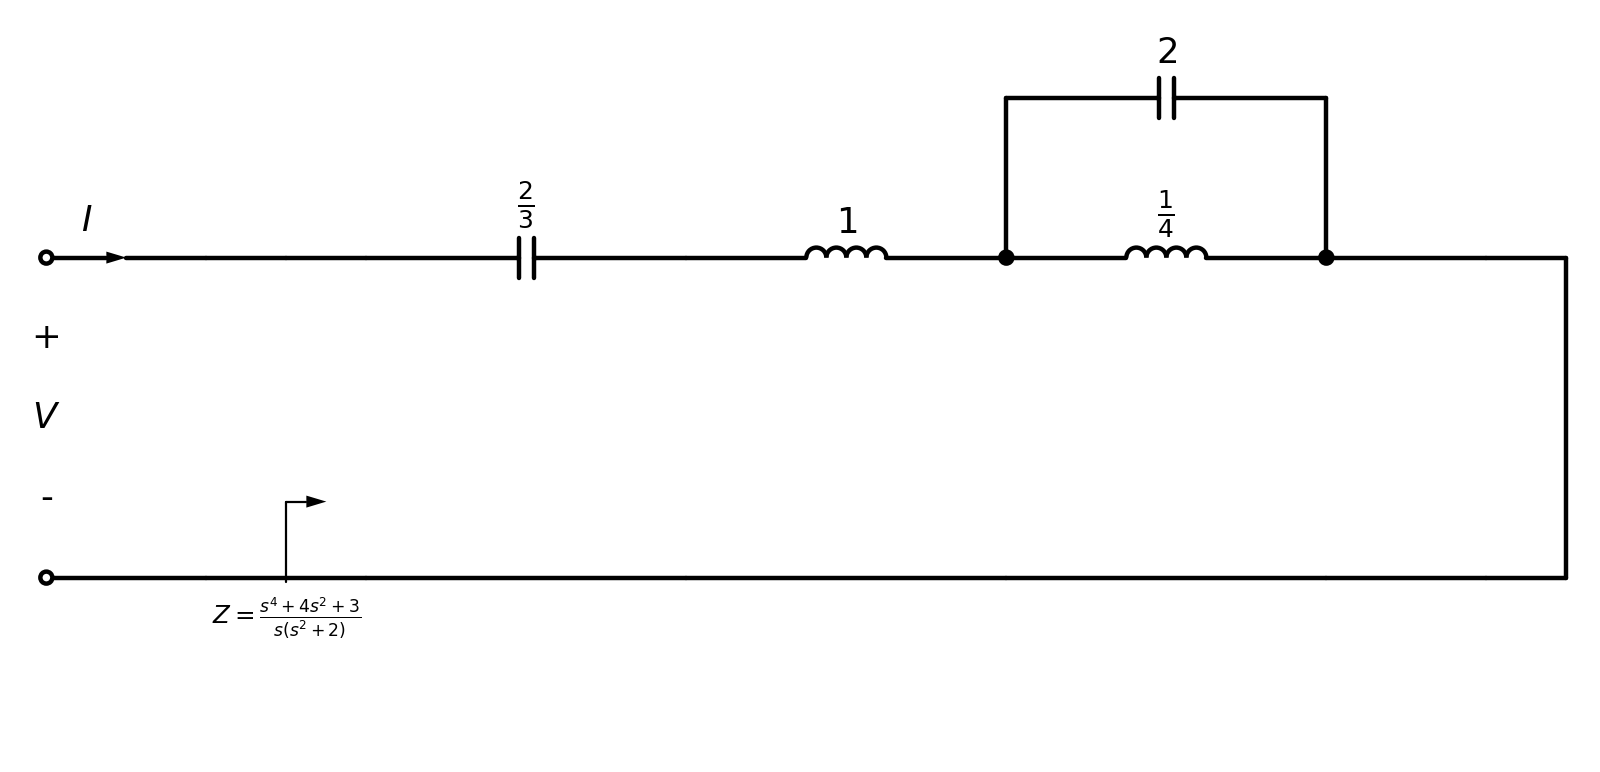

In [5]:
k0, koo, ki_wi, kk, F_foster = foster(F)
print_latex(a_equal_b_latex_s('k_0', k0))
print_latex(a_equal_b_latex_s(r'k_\infty', koo))
print_latex(a_equal_b_latex_s(r'k_{LC}', ki_wi))
print_latex(a_equal_b_latex_s('Z_{Foster}(s)', F_foster))

C1_a = sp.simplify(1/k0)
L1_a = koo
L2_a = sp.simplify(1/ki_wi[0][0])
C2_a = ki_wi[0][1]
display(Math(sp.latex(sp.Eq(sp.Symbol('C_1'), C1_a))))
display(Math(sp.latex(sp.Eq(sp.Symbol('L_1'), L1_a))))
display(Math(sp.latex(sp.Eq(sp.Symbol('L_2'), L2_a))))
display(Math(sp.latex(sp.Eq(sp.Symbol('C_2'), C2_a))))

Z_red_a = s*L1_a + 1/(s*C1_a) + 1/(s*C2_a + 1/(s*L2_a))
diferencia_a = sp.cancel(Z_red_a - F)
print_latex(a_equal_b_latex_s('Z_{red,a}(s)-F(s)', diferencia_a))
assert sp.cancel(F_foster - F) == 0
assert diferencia_a == 0
dibujar_foster_serie(k0, koo, ki_wi, z_exc=F)

### <ins>Simulación en LTspice</ins>

**Circuito simulado**

<div align="center">
    <img src="./Imagenes/Ejercicio1a/Simulacion%201a%20Circuito.png" alt="Circuito simulado, ejercicio 1a" width="600" style="max-width:100%; height:auto;" />
</div>

La impedancia se obtiene con `V(in)/(-I(V1))`. El signo negativo expresa la corriente que entra al dipolo, ya que LTspice toma la corriente de la fuente de tensión entrando por su terminal positivo.

**Módulo y fase**

<div align="center">
    <img src="./Imagenes/Ejercicio1a/Simulacion%201a%20ModuloFase.png" alt="Módulo y fase, ejercicio 1a" width="1100" style="max-width:100%; height:auto;" />
</div>

El módulo presenta dos mínimos y un máximo entre ellos, correspondientes a los dos ceros finitos y al polo finito de $Z(s)$. La fase pasa por los tramos $-90^\circ$, $+90^\circ$, $-90^\circ$ y $+90^\circ$, en orden de frecuencia creciente. La entrada es capacitiva cuando la fase de la impedancia es negativa e inductiva cuando es positiva.

**Lecturas de ceros y polos**

<div align="center">
    <img src="./Imagenes/Ejercicio1a/Simulacion%201a%20Ceros.png" alt="Cursores próximos a los ceros, ejercicio 1a" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio1a/Simulacion%201a%20Polo.png" alt="Cursores próximos a los polos, ejercicio 1a" width="290" style="max-width:100%; height:auto;" />
</div>

| Singularidad | Frecuencia teórica (mHz) | Lectura del cursor (mHz) |
|---|---:|---:|
| Cero 1 | 159,155 | 159,074 |
| Polo | 225,079 | 225,060 |
| Cero 2 | 275,664 | 275,553 |

Las lecturas se encuentran próximas a $f_{z1}=1/(2\pi)$, $f_p=\sqrt2/(2\pi)$ y $f_{z2}=\sqrt3/(2\pi)$. El máximo y los mínimos de la captura son finitos porque los cursores y el barrido toman frecuencias próximas a las singularidades. En la red ideal, el módulo tiende a infinito en el polo y a cero en los ceros; la fase no está definida en esos puntos exactos.

**Ley de variación del módulo**

<div align="center">
    <img src="./Imagenes/Ejercicio1a/Simulacion%201a%20PendienteBajaFreq.png" alt="Medición a baja frecuencia, ejercicio 1a" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio1a/Simulacion%201a%20PendienteAltaFreq.png" alt="Medición a alta frecuencia, ejercicio 1a" width="290" style="max-width:100%; height:auto;" />
</div>

La pendiente se obtiene dividiendo la variación de módulo en dB por la separación logarítmica entre las frecuencias de los cursores:

$$m=\frac{M_2-M_1}{\log_{10}(f_2/f_1)}\quad[\mathrm{dB/década}].$$

Los valores $M_1$ y $M_2$ son las lecturas del módulo en dB respecto de $1\;\Omega$.

| Zona | $f_1$ (Hz) | $f_2$ (Hz) | $M_1$ (dB) | $M_2$ (dB) | Pendiente (dB/década) |
|---|---:|---:|---:|---:|---:|
| Baja frecuencia | 0,001000 | 0,010008 | 47,558 | 27,523 | -20,028 |
| Alta frecuencia | 1,001008 | 10,010078 | 15,516 | 35,968 | 20,452 |

A baja frecuencia domina $Z(s)\sim3/(2s)$, por lo que el módulo decrece aproximadamente $20\;\mathrm{dB}$ por década. La medición da una pendiente cercana a $-20\;\mathrm{dB/década}$.

A alta frecuencia domina $Z(s)\sim s$. Entre aproximadamente $1$ y $10\;\mathrm{Hz}$ se mide $+20{,}45\;\mathrm{dB/década}$, próximo al valor asintótico $+20$.


### <ins>b) Foster en su versión derivación</ins>

Se toma la función propuesta como admitancia. Su expansión es la misma:

$$Y(s)=F(s)=s+\frac{3}{2s}+\frac{s}{2(s^2+2)}.$$

Los coeficientes se obtienen sobre la admitancia mediante los mismos límites:

$$k_\infty=\lim_{s\to\infty}\frac{Y(s)}s=1,\qquad
k_0=\lim_{s\to0}sY(s)=\frac32,\qquad
2k_1=\left.\frac{s^2+2}{s}Y(s)\right|_{s^2=-2}=\frac12.$$

En una admitancia, sumar términos corresponde a conectar ramas en paralelo. El término en infinito representa un capacitor porque $Y_C=sC$:

$$sC_1=s\quad\Longrightarrow\quad C_1=1\;\mathrm F.$$

El término en DC representa una bobina:

$$\frac1{sL_1}=\frac3{2s}
\quad\Longrightarrow\quad L_1=\frac23\;\mathrm H.$$

Para el término finito se obtiene una rama LC serie:

$$Y_{L_2+C_2}(s)=\frac{s}{2(s^2+2)}
=\frac1{2s+\frac4s}
=\frac1{sL_2+\frac1{sC_2}}.$$

Para identificar los elementos de esta rama, se invierte su admitancia:

$$Z_{L_2+C_2}(s)=\frac1{Y_{L_2+C_2}(s)}
=\frac{2(s^2+2)}s=2s+\frac4s.$$

Como los elementos están en serie, $Z_{L_2+C_2}=sL_2+1/(sC_2)$. Por comparación:

$$L_2=2\;\mathrm H,\qquad\frac1{C_2}=4
\quad\Longrightarrow\quad C_2=\frac14\;\mathrm F.$$

Se comprueba la resonancia de la rama:

$$\omega_0=\frac1{\sqrt{L_2C_2}}
=\frac1{\sqrt{2\cdot\frac14}}=\sqrt2\;\mathrm{rad/s}.$$

La admitancia de entrada queda:

$$Y(s)=sC_1+\frac1{sL_1}+\frac1{sL_2+\frac1{sC_2}}.$$

| Componente | Valor | Conexión |
|---|---|---|
| $C_1$ | $1\;\mathrm F$ | Derivación |
| $L_1$ | $2/3\;\mathrm H$ | Derivación |
| $L_2$ | $2\;\mathrm H$ | Rama LC serie |
| $C_2$ | $1/4\;\mathrm F$ | Rama LC serie |

### <ins>Circuito obtenido</ins>

<div align="center">
    <img src="./Imagenes/TS7_circuito_1b.png" alt="Foster en derivación: nombres y valores de los componentes" width="400" />
</div>

### <ins>Verificación en Python con PyTC2</ins>

Los parámetros $[4,2]$ que entrega `foster` se interpretan ahora como $[1/C_2,L_2]$. El circuito se representa con las primitivas de dibujo de PyTC2, conectando en paralelo la bobina, el capacitor y la rama LC serie.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

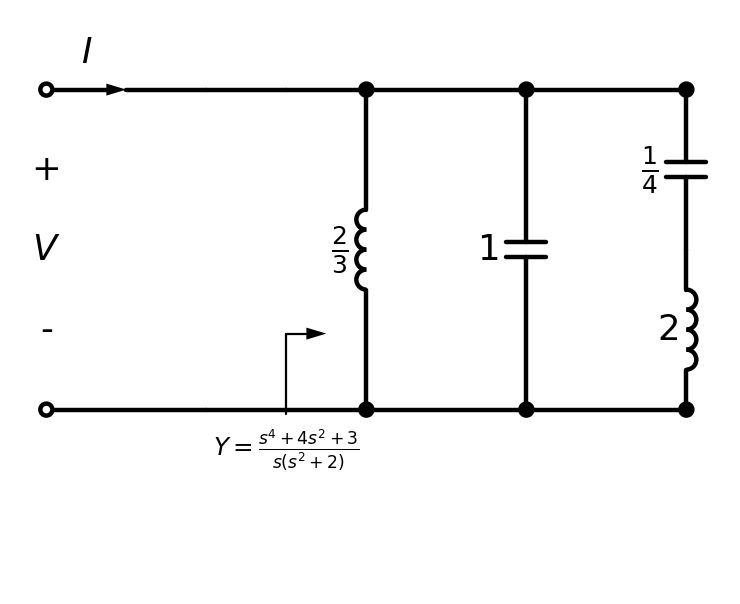

In [6]:
k0_b, koo_b, ki_wi_b, kk_b, Y_foster = foster(F)
C1_b = koo_b
L1_b = sp.simplify(1/k0_b)
C2_b = sp.simplify(1/ki_wi_b[0][0])
L2_b = ki_wi_b[0][1]

print_latex(a_equal_b_latex_s('Y_{Foster}(s)', Y_foster))
for nombre, valor in [('C_1', C1_b), ('L_1', L1_b), ('L_2', L2_b), ('C_2', C2_b)]:
    print_latex(a_equal_b_latex_s(nombre, valor))

Y_red_b = s*C1_b + 1/(s*L1_b) + 1/(s*L2_b + 1/(s*C2_b))
diferencia_b = sp.cancel(Y_red_b - F)
print_latex(a_equal_b_latex_s('Y_{red,b}(s)-F(s)', diferencia_b))
assert sp.cancel(Y_foster - F) == 0
assert diferencia_b == 0
dibujar_foster_derivacion_lc(k0_b, koo_b, ki_wi_b, y_exc=F)

### <ins>Simulación en LTspice</ins>

**Circuito simulado**

<div align="center">
    <img src="./Imagenes/Ejercicio1b/Simulacion%201b%20Circuito.png" alt="Circuito simulado, ejercicio 1b" width="600" style="max-width:100%; height:auto;" />
</div>

En este inciso se mide la **admitancia**, mediante `I(I1)/V(in)`. Por lo tanto, el módulo está expresado en dB respecto de $1\;\mathrm S$.

**Módulo y fase**

<div align="center">
    <img src="./Imagenes/Ejercicio1b/Simulacion%201b%20ModuloFase.png" alt="Módulo y fase, ejercicio 1b" width="1100" style="max-width:100%; height:auto;" />
</div>

La admitancia presenta dos mínimos y un máximo, en el mismo orden que sus ceros y polo finitos. La fase recorre los tramos $-90^\circ$, $+90^\circ$, $-90^\circ$ y $+90^\circ$.

Para una admitancia, $-90^\circ$ indica carácter inductivo y $+90^\circ$ carácter capacitivo. La fase de la impedancia de este mismo circuito es la opuesta, porque $Z=1/Y$.

**Lecturas de ceros y polos**

<div align="center">
    <img src="./Imagenes/Ejercicio1b/Simulacion%201b%20Ceros.png" alt="Cursores próximos a los ceros, ejercicio 1b" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio1b/Simulacion%201b%20Polo.png" alt="Cursores próximos a los polos, ejercicio 1b" width="290" style="max-width:100%; height:auto;" />
</div>

| Singularidad | Frecuencia teórica (mHz) | Lectura del cursor (mHz) |
|---|---:|---:|
| Cero 1 | 159,155 | 159,143 |
| Polo | 225,079 | 225,069 |
| Cero 2 | 275,664 | 275,712 |

Las lecturas de frecuencia se aproximan a los valores calculados para $Y(s)$. Las fases cercanas a $-25^\circ$ que aparecen en los cursores ubicados junto a los nulos no se interpretan como la fase ideal de un cero: allí el módulo se aproxima a cero y la lectura entre puntos del barrido puede dar valores intermedios durante el salto. La interpretación se realiza sobre los tramos a ambos lados del nulo; en el cero exacto, la fase no está definida.

**Ley de variación del módulo**

<div align="center">
    <img src="./Imagenes/Ejercicio1b/Simulacion%201b%20PendienteBajaFreq.png" alt="Medición a baja frecuencia, ejercicio 1b" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio1b/Simulacion%201b%20PendienteAltaFreq.png" alt="Medición a alta frecuencia, ejercicio 1b" width="290" style="max-width:100%; height:auto;" />
</div>

La pendiente se obtiene dividiendo la variación de módulo en dB por la separación logarítmica entre las frecuencias de los cursores:

$$m=\frac{M_2-M_1}{\log_{10}(f_2/f_1)}\quad[\mathrm{dB/década}].$$

Los valores $M_1$ y $M_2$ son las lecturas del módulo en dB respecto de $1\;\mathrm S$.

| Zona | $f_1$ (Hz) | $f_2$ (Hz) | $M_1$ (dB) | $M_2$ (dB) | Pendiente (dB/década) |
|---|---:|---:|---:|---:|---:|
| Baja frecuencia | 0,001000 | 0,010011 | 47,558 | 27,520 | -20,028 |
| Alta frecuencia | 1,000000 | 10,000000 | 15,506 | 35,959 | 20,453 |

En DC domina $Y(s)\sim3/(2s)$, la admitancia de una bobina, y se obtiene una pendiente próxima a $-20\;\mathrm{dB/década}$. A alta frecuencia domina $Y(s)\sim s$, la admitancia de un capacitor.

La lectura entre aproximadamente $1$ y $10\;\mathrm{Hz}$ da $+20{,}45\;\mathrm{dB/década}$. La pequeña diferencia respecto de $+20$ se debe a que el primer punto todavía recibe el aporte de los otros términos de la función; la pendiente tiende a $+20$ al aumentar la frecuencia.


### <ins>c) Cauer con remociones en infinito</ins>

Se remueve el polo en infinito y se invierte el remanente para alternar entre impedancia y admitancia. Si se extrae un término $ks$ de una impedancia, se obtiene una bobina serie de valor $L=k$. Si se extrae de una admitancia, se obtiene un capacitor en derivación de valor $C=k$.

En cada paso, el coeficiente se calcula dividiendo la inmitancia por $s$ y tomando el límite en infinito.

**Primera remoción: bobina serie.**

$$k_{\infty,1}=\lim_{s\to\infty}\frac{Z(s)}s=1
\quad\Longrightarrow\quad L_1=1\;\mathrm H.$$

Para obtener el remanente se escribe la resta con denominador común:

$$\begin{aligned}
Z_{2,\infty}&=Z-s\\
&=\frac{s^4+4s^2+3-s^2(s^2+2)}{s(s^2+2)}\\
&=\frac{s^4+4s^2+3-s^4-2s^2}{s(s^2+2)}\\
&=\frac{2s^2+3}{s(s^2+2)}.
\end{aligned}$$

Como el siguiente elemento se conecta en derivación, se invierte el remanente:

$$Y_{2,\infty}=\frac1{Z_{2,\infty}}=\frac{s(s^2+2)}{2s^2+3}.$$

**Segunda remoción: capacitor en derivación.**

$$k_{\infty,2}=\lim_{s\to\infty}\frac{Y_{2,\infty}}s
=\lim_{s\to\infty}\frac{s^2+2}{2s^2+3}=\frac12.$$

Se extrae $Y_{C_1}=s/2=sC_1$, de donde $C_1=1/2\;\mathrm F$.

$$\begin{aligned}
Y_{4,\infty}&=\frac{s(s^2+2)}{2s^2+3}-\frac s2\\
&=\frac{2s(s^2+2)-s(2s^2+3)}{2(2s^2+3)}\\
&=\frac{2s^3+4s-2s^3-3s}{2(2s^2+3)}
=\frac{s}{2(2s^2+3)}.
\end{aligned}$$

Al invertirlo y dividir cada término por $s$:

$$Z_{4,\infty}=\frac{2(2s^2+3)}s=\frac{4s^2+6}s=4s+\frac6s.$$

**Tercera remoción: segunda bobina serie.**

$$k_{\infty,3}=\lim_{s\to\infty}\frac{4s+6/s}{s}
=\lim_{s\to\infty}\left(4+\frac6{s^2}\right)=4.$$

El término extraído es $Z_{L_2}=4s=sL_2$, por lo que $L_2=4\;\mathrm H$.

$$Z_{6,\infty}=Z_{4,\infty}-4s=\frac6s,\qquad
Y_{6,\infty}=\frac s6.$$

**Cuarta remoción: capacitor final en derivación.**

$$k_{\infty,4}=\lim_{s\to\infty}\frac{Y_{6,\infty}}s=\frac16
\quad\Longrightarrow\quad C_2=\frac16\;\mathrm F.$$

$$Y_{8,\infty}=Y_{6,\infty}-\frac s6=0.$$

Para reconstruir la fracción continua se siguen las inversiones realizadas:

$$Z=s+Z_{2,\infty},\qquad
Z_{2,\infty}=\frac1{Y_{2,\infty}},\qquad
Y_{2,\infty}=\frac s2+\frac1{Z_{4,\infty}},\qquad
Z_{4,\infty}=4s+\frac6s.$$

Sustituyendo desde el último remanente hacia la entrada, la fracción continua resultante es:

$$\boxed{Z(s)=s+\cfrac1{\frac s2+\cfrac1{4s+\frac6s}}}.$$

La red escalera comienza con $L_1$ serie, sigue con $C_1$ en derivación, $L_2$ serie y termina con $C_2$ en derivación.

| Componente | Valor |
|---|---|
| $L_1$ | $1\;\mathrm H$ |
| $C_1$ | $1/2\;\mathrm F$ |
| $L_2$ | $4\;\mathrm H$ |
| $C_2$ | $1/6\;\mathrm F$ |

### <ins>Circuito obtenido</ins>

<div align="center">
    <img src="./Imagenes/TS7_circuito_1c.png" alt="Cauer con remociones en infinito: nombres y valores de los componentes" width="500" />
</div>

### <ins>Verificación en Python con PyTC2</ins>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

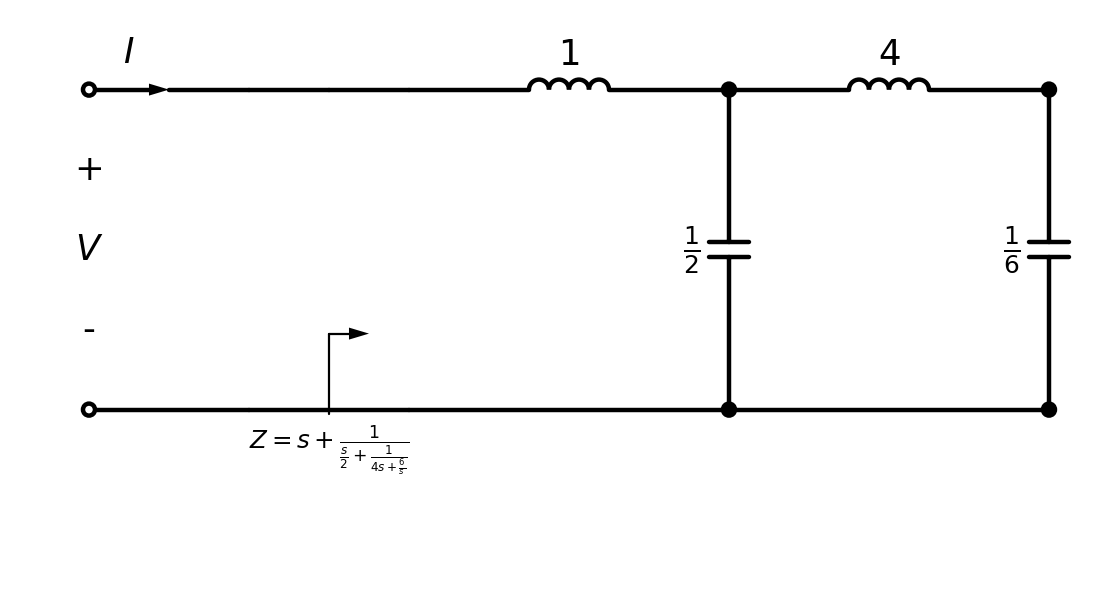

In [15]:
terminos_inf, Z_cauer_inf, rem_inf = cauer_LC(F, remover_en_inf=True)
print_latex(a_equal_b_latex_s(r'\mathrm{Términos\ extraídos}', terminos_inf))
print_latex(a_equal_b_latex_s(r'Z_{Cauer,\infty}(s)', Z_cauer_inf))
print_latex(a_equal_b_latex_s(r'\mathrm{Remanente}', rem_inf))

L1_c, C1_c, L2_c, C2_c = [sp.simplify(t/s) for t in terminos_inf]
for nombre, valor in [('L_1', L1_c), ('C_1', C1_c), ('L_2', L2_c), ('C_2', C2_c)]:
    print_latex(a_equal_b_latex_s(nombre, valor))

Z_red_c = s*L1_c + 1/(s*C1_c + 1/(s*L2_c + 1/(s*C2_c)))
diferencia_c = sp.cancel(Z_red_c - F)
print_latex(a_equal_b_latex_s('Z_{red,c}(s)-F(s)', diferencia_c))
assert sp.cancel(Z_cauer_inf - F) == 0
assert diferencia_c == 0 and rem_inf == 0
dibujar_cauer_LC(terminos_inf, z_exc=Z_cauer_inf)

### <ins>Simulación en LTspice</ins>

**Circuito simulado**

<div align="center">
    <img src="./Imagenes/Ejercicio1c/Simulacion%201c%20Circuito.png" alt="Circuito simulado, ejercicio 1c" width="600" style="max-width:100%; height:auto;" />
</div>

**Módulo y fase**

<div align="center">
    <img src="./Imagenes/Ejercicio1c/Simulacion%201c%20ModuloFase.png" alt="Módulo y fase, ejercicio 1c" width="1100" style="max-width:100%; height:auto;" />
</div>

Se observan dos mínimos de impedancia, separados por un máximo. Esta escalera reproduce la función de entrada $Z(s)=F(s)$, aunque su conexión de elementos sea distinta de la realización Foster. La fase alterna entre $-90^\circ$ y $+90^\circ$: la entrada es capacitiva por debajo del primer cero, inductiva hasta el polo, capacitiva hasta el segundo cero e inductiva a frecuencias superiores.

**Lecturas de ceros y polos**

<div align="center">
    <img src="./Imagenes/Ejercicio1c/Simulacion%201c%20Ceros.png" alt="Cursores próximos a los ceros, ejercicio 1c" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio1c/Simulacion%201c%20Polo.png" alt="Cursores próximos a los polos, ejercicio 1c" width="290" style="max-width:100%; height:auto;" />
</div>

| Singularidad | Frecuencia teórica (mHz) | Lectura del cursor (mHz) |
|---|---:|---:|
| Cero 1 | 159,155 | 159,076 |
| Polo | 225,079 | 225,056 |
| Cero 2 | 275,664 | 275,617 |

Los cursores permiten localizar las singularidades cerca de las frecuencias teóricas. El pico finito de la simulación y la profundidad finita de los nulos dependen de las frecuencias muestreadas y de la ubicación de los cursores. El modelo LC ideal conserva un polo de módulo infinito y ceros de módulo nulo.

**Ley de variación del módulo**

<div align="center">
    <img src="./Imagenes/Ejercicio1c/Simulacion%201c%20PendienteBajaFreq.png" alt="Medición a baja frecuencia, ejercicio 1c" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio1c/Simulacion%201c%20PendienteAltaFreq.png" alt="Medición a alta frecuencia, ejercicio 1c" width="290" style="max-width:100%; height:auto;" />
</div>

La pendiente se obtiene dividiendo la variación de módulo en dB por la separación logarítmica entre las frecuencias de los cursores:

$$m=\frac{M_2-M_1}{\log_{10}(f_2/f_1)}\quad[\mathrm{dB/década}].$$

Los valores $M_1$ y $M_2$ son las lecturas del módulo en dB respecto de $1\;\Omega$.

| Zona | $f_1$ (Hz) | $f_2$ (Hz) | $M_1$ (dB) | $M_2$ (dB) | Pendiente (dB/década) |
|---|---:|---:|---:|---:|---:|
| Baja frecuencia | 0,001000 | 0,010008 | 47,558 | 27,523 | -20,028 |
| Alta frecuencia | 1,001170 | 10,011704 | 15,517 | 35,969 | 20,452 |

A baja frecuencia domina $Z(s)\sim3/(2s)$, por lo que el módulo decrece aproximadamente $20\;\mathrm{dB}$ por década. La medición da una pendiente cercana a $-20\;\mathrm{dB/década}$.

A alta frecuencia domina $Z(s)\sim s$. Entre aproximadamente $1$ y $10\;\mathrm{Hz}$ se mide $+20{,}45\;\mathrm{dB/década}$, próximo al valor asintótico $+20$. 


### <ins>d) Cauer con remociones en DC</ins>

Se remueve el polo en el origen y se invierte el remanente en cada paso. El coeficiente de cada término $k_0/s$ se obtiene multiplicando la inmitancia por $s$ y tomando el límite en DC.

Para una impedancia, $k_0/s=1/(sC)$ implica $C=1/k_0$. Para una admitancia, $k_0/s=1/(sL)$ implica $L=1/k_0$.

**Primera remoción: capacitor serie.**

$$k_{0,1}=\lim_{s\to0}sZ(s)=\frac32=\frac1{C_1}
\quad\Longrightarrow\quad C_1=\frac23\;\mathrm F.$$

La resta se resuelve usando $2s(s^2+2)$ como denominador común:

$$\begin{aligned}
Z_{2,0}&=\frac{s^4+4s^2+3}{s(s^2+2)}-\frac3{2s}\\
&=\frac{2(s^4+4s^2+3)-3(s^2+2)}{2s(s^2+2)}\\
&=\frac{2s^4+8s^2+6-3s^2-6}{2s(s^2+2)}\\
&=\frac{s^2(2s^2+5)}{2s(s^2+2)}
=\frac{s(2s^2+5)}{2(s^2+2)}.
\end{aligned}$$

La admitancia de la red restante es:

$$Y_{2,0}=\frac1{Z_{2,0}}=\frac{2(s^2+2)}{s(2s^2+5)}.$$

**Segunda remoción: bobina en derivación.**

$$k_{0,2}=\lim_{s\to0}sY_{2,0}
=\lim_{s\to0}\frac{2(s^2+2)}{2s^2+5}
=\frac{2\cdot2}{5}=\frac45.$$

La admitancia extraída cumple $4/(5s)=1/(sL_1)$, por lo que $1/L_1=4/5$ y $L_1=5/4\;\mathrm H$.

$$\begin{aligned}
Y_{4,0}&=\frac{2(s^2+2)}{s(2s^2+5)}-\frac4{5s}\\
&=\frac{10(s^2+2)-4(2s^2+5)}{5s(2s^2+5)}\\
&=\frac{10s^2+20-8s^2-20}{5s(2s^2+5)}\\
&=\frac{2s^2}{5s(2s^2+5)}=\frac{2s}{5(2s^2+5)}.
\end{aligned}$$

Se vuelve a trabajar con impedancia:

$$Z_{4,0}=\frac{5(2s^2+5)}{2s}
=\frac{10s^2+25}{2s}=5s+\frac{25}{2s}.$$

**Tercera remoción: segundo capacitor serie.**

$$k_{0,3}=\lim_{s\to0}sZ_{4,0}=\frac{25}2=\frac1{C_2}
\quad\Longrightarrow\quad C_2=\frac2{25}\;\mathrm F.$$

$$Z_{6,0}=Z_{4,0}-\frac{25}{2s}=5s,\qquad
Y_{6,0}=\frac1{5s}.$$

**Cuarta remoción: bobina final en derivación.**

$$k_{0,4}=\lim_{s\to0}sY_{6,0}=\frac15=\frac1{L_2}
\quad\Longrightarrow\quad L_2=5\;\mathrm H.$$

$$Y_{8,0}=Y_{6,0}-\frac1{5s}=0.$$

La reconstrucción desde el último remanente cumple:

$$Z=\frac3{2s}+Z_{2,0},\qquad
Z_{2,0}=\frac1{Y_{2,0}},\qquad
Y_{2,0}=\frac4{5s}+\frac1{Z_{4,0}},\qquad
Z_{4,0}=\frac{25}{2s}+5s.$$

Al sustituir estas relaciones, la fracción continua es:

$$\boxed{Z(s)=\frac3{2s}+\cfrac1{\frac4{5s}+\cfrac1{\frac{25}{2s}+5s}}}.$$

La red comienza con $C_1$ serie, sigue con $L_1$ en derivación, $C_2$ serie y termina con $L_2$ en derivación.

| Componente | Valor |
|---|---|
| $C_1$ | $2/3\;\mathrm F$ |
| $L_1$ | $5/4\;\mathrm H$ |
| $C_2$ | $2/25\;\mathrm F$ |
| $L_2$ | $5\;\mathrm H$ |

### <ins>Circuito obtenido</ins>

<div align="center">
    <img src="./Imagenes/TS7_circuito_1d.png" alt="Cauer con remociones en DC: nombres y valores de los componentes" width="500" />
</div>

### <ins>Verificación en Python con PyTC2</ins>

Los términos de esta expansión son proporcionales a $1/s$. Sus coeficientes representan los inversos de las capacidades e inductancias correspondientes.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

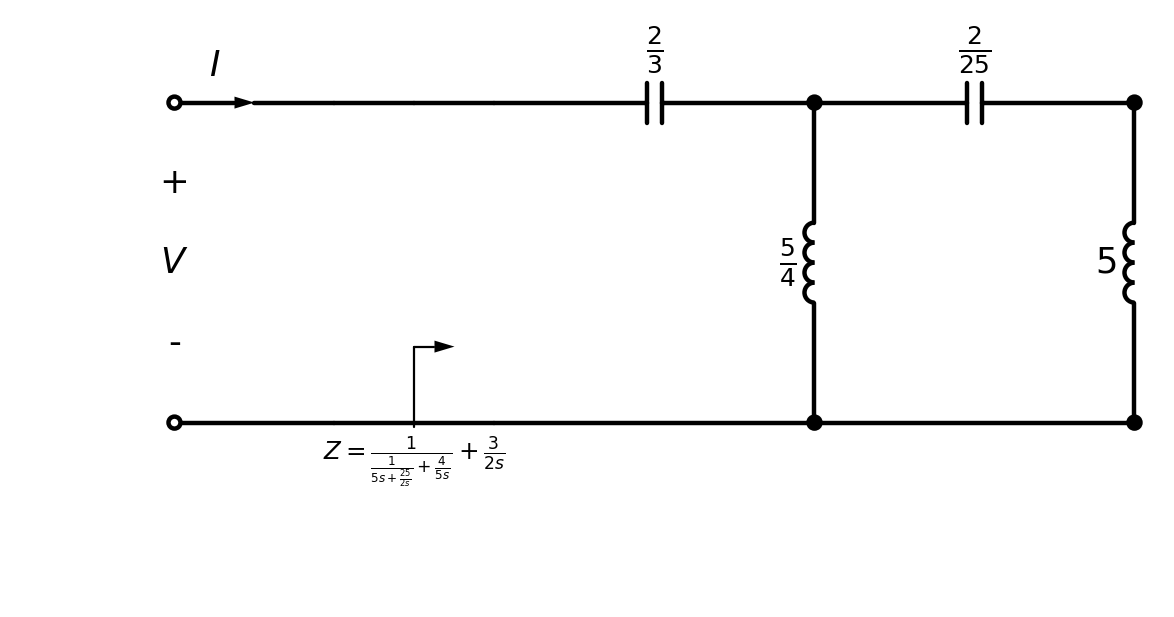

In [8]:
terminos_dc, Z_cauer_dc, rem_dc = cauer_LC(F, remover_en_inf=False)
print_latex(a_equal_b_latex_s(r'\mathrm{Términos\ extraídos}', terminos_dc))
print_latex(a_equal_b_latex_s('Z_{Cauer,0}(s)', Z_cauer_dc))
print_latex(a_equal_b_latex_s(r'\mathrm{Remanente}', rem_dc))

C1_d, L1_d, C2_d, L2_d = [sp.simplify(1/(s*t)) for t in terminos_dc]
for nombre, valor in [('C_1', C1_d), ('L_1', L1_d), ('C_2', C2_d), ('L_2', L2_d)]:
    print_latex(a_equal_b_latex_s(nombre, valor))

Z_red_d = 1/(s*C1_d) + 1/(1/(s*L1_d) + 1/(1/(s*C2_d) + s*L2_d))
diferencia_d = sp.cancel(Z_red_d - F)
print_latex(a_equal_b_latex_s('Z_{red,d}(s)-F(s)', diferencia_d))
assert sp.cancel(Z_cauer_dc - F) == 0
assert diferencia_d == 0 and rem_dc == 0
dibujar_cauer_LC(terminos_dc, z_exc=Z_cauer_dc)

### <ins>Simulación en LTspice</ins>

**Circuito simulado**

<div align="center">
    <img src="./Imagenes/Ejercicio%201d/Simulacion%201d%20Circuito.png" alt="Circuito simulado, ejercicio 1d" width="600" style="max-width:100%; height:auto;" />
</div>

**Módulo y fase**

<div align="center">
    <img src="./Imagenes/Ejercicio%201d/Simulacion%201d%20ModuloFase.png" alt="Módulo y fase, ejercicio 1d" width="1100" style="max-width:100%; height:auto;" />
</div>

El módulo conserva los dos ceros finitos y el polo finito de la función propuesta. La fase comienza en $-90^\circ$, cambia a $+90^\circ$ al atravesar el primer cero, vuelve a $-90^\circ$ al atravesar el polo y termina en $+90^\circ$ después del segundo cero. La red obtenida por remociones en DC reproduce así la impedancia de entrada calculada.

**Lecturas de ceros y polos**

<div align="center">
    <img src="./Imagenes/Ejercicio%201d/Simulacion%201d%20Ceros.png" alt="Cursores próximos a los ceros, ejercicio 1d" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio%201d/Simulacion%201d%20Polo.png" alt="Cursores próximos a los polos, ejercicio 1d" width="290" style="max-width:100%; height:auto;" />
</div>

| Singularidad | Frecuencia teórica (mHz) | Lectura del cursor (mHz) |
|---|---:|---:|
| Cero 1 | 159,155 | 159,081 |
| Polo | 225,079 | 225,078 |
| Cero 2 | 275,664 | 275,407 |

Los mínimos y el máximo se encuentran próximos a las frecuencias teóricas. La segunda lectura de cero está algo más alejada del nulo que la primera, por lo que su módulo resulta menos negativo. Esa profundidad no modifica la ubicación teórica del cero ni implica que las dos realizaciones tengan funciones distintas.

**Ley de variación del módulo**

<div align="center">
    <img src="./Imagenes/Ejercicio%201d/Simulacion%201d%20PendienteBajaFreq.png" alt="Medición a baja frecuencia, ejercicio 1d" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio%201d/Simulacion%201d%20PendienteAltaFreq.png" alt="Medición a alta frecuencia, ejercicio 1d" width="290" style="max-width:100%; height:auto;" />
</div>

La pendiente se obtiene dividiendo la variación de módulo en dB por la separación logarítmica entre las frecuencias de los cursores:

$$m=\frac{M_2-M_1}{\log_{10}(f_2/f_1)}\quad[\mathrm{dB/década}].$$

Los valores $M_1$ y $M_2$ son las lecturas del módulo en dB respecto de $1\;\Omega$.

| Zona | $f_1$ (Hz) | $f_2$ (Hz) | $M_1$ (dB) | $M_2$ (dB) | Pendiente (dB/década) |
|---|---:|---:|---:|---:|---:|
| Baja frecuencia | 0,001000 | 0,010011 | 47,558 | 27,520 | -20,028 |
| Alta frecuencia | 1,001574 | 10,015738 | 15,521 | 35,973 | 20,452 |

A baja frecuencia domina $Z(s)\sim3/(2s)$, por lo que el módulo decrece aproximadamente $20\;\mathrm{dB}$ por década. La medición da una pendiente cercana a $-20\;\mathrm{dB/década}$.

A alta frecuencia domina $Z(s)\sim s$. Entre aproximadamente $1$ y $10\;\mathrm{Hz}$ se mide $+20{,}45\;\mathrm{dB/década}$, próximo al valor asintótico $+20$. La diferencia se explica porque el primer punto aún recibe el aporte de los términos restantes de $Z(s)$.


### <ins>Módulo, fase y ley de variación de la impedancia</ins>

Las realizaciones a), c) y d) tienen la misma impedancia de entrada. Evaluando $s=j\omega$:

$$Z(j\omega)=-j\,\frac{(\omega^2-1)(\omega^2-3)}{\omega(2-\omega^2)}.$$

Los ceros finitos y el polo finito corresponden a:

$$f_{z1}=\frac1{2\pi}\approx0{,}15915\;\mathrm{Hz},\quad
f_p=\frac{\sqrt2}{2\pi}\approx0{,}22508\;\mathrm{Hz},\quad
f_{z2}=\frac{\sqrt3}{2\pi}\approx0{,}27566\;\mathrm{Hz}.$$

| Intervalo de $\omega$ | Carácter de $Z$ | Fase |
|---|---|---|
| $0<\omega<1$ | Capacitivo | $-90^\circ$ |
| $1<\omega<\sqrt2$ | Inductivo | $+90^\circ$ |
| $\sqrt2<\omega<\sqrt3$ | Capacitivo | $-90^\circ$ |
| $\omega>\sqrt3$ | Inductivo | $+90^\circ$ |

La fase no se define en los ceros ni en el polo ideal. A baja frecuencia domina $3/(2s)$, por lo que $|Z|\propto1/f$ y la pendiente asintótica es $-20\;\mathrm{dB/década}$. A alta frecuencia domina $s$, entonces $|Z|\propto f$ y la pendiente es $+20\;\mathrm{dB/década}$.

La pendiente se mide como $\Delta(20\log_{10}|Z|)/\Delta\log_{10}f$. Cerca de las singularidades no permanece constante. Para medirla en LTspice deben elegirse dos frecuencias de una misma zona asintótica sobre un eje logarítmico.

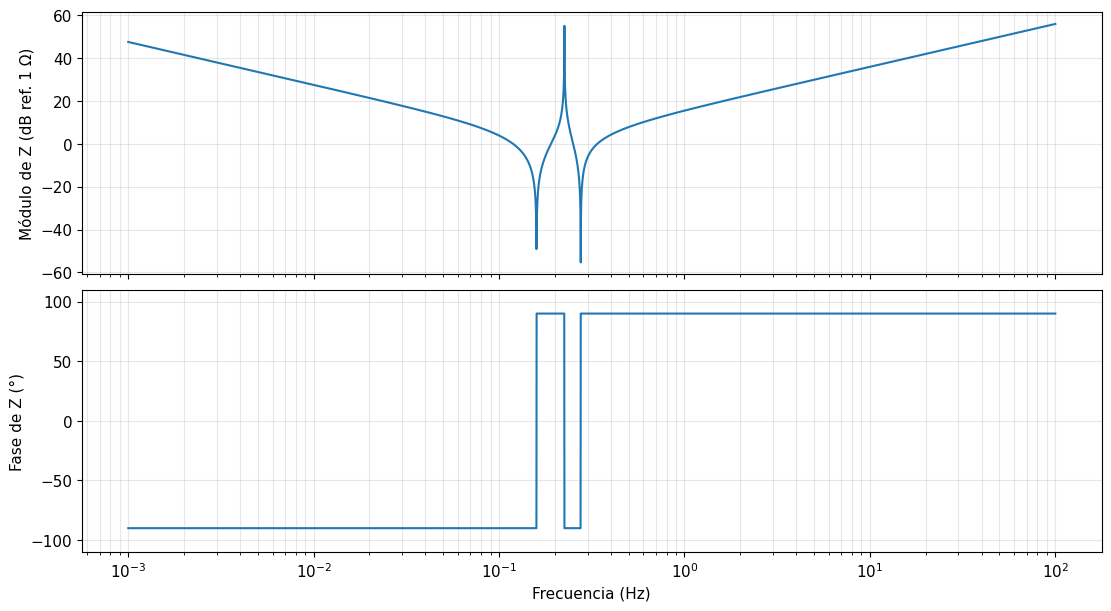

In [9]:
frecuencias = np.logspace(-3, 2, 5000)
Z_jw = sp.lambdify(s, F, 'numpy')(2j*np.pi*frecuencias)
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
ax[0].semilogx(frecuencias, 20*np.log10(np.abs(Z_jw)))
ax[0].set_ylabel('Módulo de Z (dB ref. 1 Ω)')
ax[1].semilogx(frecuencias, np.angle(Z_jw, deg=True))
ax[1].set_ylabel('Fase de Z (°)')
ax[1].set_xlabel('Frecuencia (Hz)')
ax[1].set_ylim(-110, 110)
for eje in ax:
    eje.grid(True, which='both', alpha=0.3)
plt.show()

---
## <ins>2. Síntesis mediante remociones gráficas</ins>

$$Y(s)=\frac{s(s^4+18s^2+48)}{6(s^4+7s^2+8)}.$$

<div align="center">
    <img src="./Imagenes/Enunciado2.png" alt="Topología propuesta para el ejercicio 2" width="350" />
</div>

La topología propuesta comienza con un capacitor en serie. Por eso la primera remoción se realiza sobre $Z=1/Y$:

$$Z(s)=\frac{6s^4+42s^2+48}{s(s^4+18s^2+48)}.$$

### <ins>Polos y ceros iniciales</ins>

Para los polos finitos de $Y$, se reemplaza $s^2=-\omega^2$ en el denominador:

$$(-\omega^2)^2+7(-\omega^2)+8=0
\quad\Longrightarrow\quad\omega^4-7\omega^2+8=0.$$

Se define $x=\omega^2$ para resolver una cuadrática:

$$x^2-7x+8=0,\qquad
x=\frac{7\pm\sqrt{7^2-4\cdot8}}2=\frac{7\pm\sqrt{17}}2.$$

Tomando las raíces positivas y ordenándolas:

$$\omega_{p1}=\sqrt{\frac{7-\sqrt{17}}2}\approx1{,}19935,\qquad
\omega_{p2}=\sqrt{\frac{7+\sqrt{17}}2}\approx2{,}35829.$$

Para los ceros finitos distintos del origen:

$$\omega^4-18\omega^2+48=0
\quad\Longrightarrow\quad x^2-18x+48=0.$$

$$x=\frac{18\pm\sqrt{18^2-4\cdot48}}2
=\frac{18\pm\sqrt{132}}2=9\pm\sqrt{33}.$$

$$\omega_{z1}=\sqrt{9-\sqrt{33}}\approx1{,}80428,\qquad
\omega_{z2}=\sqrt{9+\sqrt{33}}\approx3{,}83986.$$

Además, el factor $s$ del numerador da un cero en DC. Como $Y(s)\sim s/6$ para $s\to\infty$, la admitancia tiene un polo en infinito.

El orden en el semieje $j\omega$ es:

$$0\;(C)<1{,}19935\;(P)<1{,}80428\;(C)<2{,}35829\;(P)
<3{,}83986\;(C)<\infty\;(P).$$

Al invertir la función, los polos y ceros intercambian sus posiciones. En el mapa se representa únicamente $\omega\geq0$; el semieje negativo se obtiene por simetría.

### <ins>Primera remoción: capacitor serie $C_1$</ins>

$$k_{0,Z}=\lim_{s\to0}sZ(s)
=\lim_{s\to0}\frac{6s^4+42s^2+48}{s^4+18s^2+48}
=\frac{48}{48}=1.$$

Por lo tanto, $Z_{C_1}=1/s=1/(sC_1)$ y $C_1=1\;\mathrm F$. El remanente se calcula como:

$$\begin{aligned}
Z_2&=\frac{6s^4+42s^2+48}{s(s^4+18s^2+48)}-\frac1s\\
&=\frac{6s^4+42s^2+48-(s^4+18s^2+48)}{s(s^4+18s^2+48)}\\
&=\frac{5s^4+24s^2}{s(s^4+18s^2+48)}
=\frac{s(5s^2+24)}{s^4+18s^2+48}.
\end{aligned}$$

$$\boxed{C_1=1\;\mathrm F},\qquad
\boxed{Z_2=Z-\frac1s=\frac{s(5s^2+24)}{s^4+18s^2+48}}.$$

La remoción total elimina el polo en el origen. Los polos finitos de $Z$ permanecen en $1{,}80428$ y $3{,}83986\;\mathrm{rad/s}$. Los ceros se desplazan de $1{,}19935$ a $0$, y de $2{,}35829$ a $\sqrt{24/5}=2{,}19089\;\mathrm{rad/s}$. El cero en infinito permanece.

### <ins>Segunda remoción: bobina en derivación $L_1$</ins>

Se invierte el remanente para trabajar con la admitancia de la bobina:

$$Y_2=\frac1{Z_2}=\frac{s^4+18s^2+48}{s(5s^2+24)}.$$

$$k_{0,Y_2}=\lim_{s\to0}sY_2(s)
=\lim_{s\to0}\frac{s^4+18s^2+48}{5s^2+24}
=\frac{48}{24}=2.$$

Se extrae $Y_{L_1}=2/s=1/(sL_1)$, de donde $L_1=1/2\;\mathrm H$. La resta da:

$$\begin{aligned}
Y_4&=\frac{s^4+18s^2+48}{s(5s^2+24)}-\frac2s\\
&=\frac{s^4+18s^2+48-2(5s^2+24)}{s(5s^2+24)}\\
&=\frac{s^4+8s^2}{s(5s^2+24)}
=\frac{s(s^2+8)}{5s^2+24}.
\end{aligned}$$

$$\boxed{L_1=\frac12\;\mathrm H},\qquad
\boxed{Y_4=Y_2-\frac2s=\frac{s(s^2+8)}{5s^2+24}}.$$

Se elimina el polo en el origen de $Y_2$. Permanecen el polo en $2{,}19089\;\mathrm{rad/s}$ y el de infinito. Los ceros se desplazan de $1{,}80428$ a $0$, y de $3{,}83986$ a $\sqrt8=2{,}82843\;\mathrm{rad/s}$.

### <ins>Tercera remoción: tanque paralelo $L_2\parallel C_2$</ins>

Se invierte nuevamente para obtener la impedancia del tanque y del capacitor final:

$$Z_4=\frac1{Y_4}=\frac{5s^2+24}{s(s^2+8)}.$$

El tanque tiene polos en $s=\pm j\sqrt8$. Su término se escribe como $As/(s^2+8)$, donde:

$$A=\left.\frac{s^2+8}{s}Z_4(s)\right|_{s^2=-8}
=\left.\frac{5s^2+24}{s^2}\right|_{s^2=-8}
=\frac{-40+24}{-8}=2.$$

$$Z_{L_2\parallel C_2}=\frac{2s}{s^2+8}
=\frac1{\frac s2+\frac4s}
=\frac1{sC_2+\frac1{sL_2}}.$$

$$\boxed{C_2=\frac12\;\mathrm F},\qquad\boxed{L_2=\frac14\;\mathrm H}.$$

La comparación del denominador de la impedancia del tanque da:

$$sC_2+\frac1{sL_2}=\frac s2+\frac4s
\quad\Longrightarrow\quad C_2=\frac12,\quad\frac1{L_2}=4.$$

Su resonancia verifica $\omega_0=1/\sqrt{L_2C_2}=\sqrt8\;\mathrm{rad/s}$. Al removerlo se obtiene:

$$\begin{aligned}
Z_6&=\frac{5s^2+24}{s(s^2+8)}-\frac{2s}{s^2+8}\\
&=\frac{5s^2+24-2s^2}{s(s^2+8)}\\
&=\frac{3s^2+24}{s(s^2+8)}
=\frac{3(s^2+8)}{s(s^2+8)}.
\end{aligned}$$

Se cancela el factor $s^2+8$, por lo que $\boxed{Z_6=3/s}$ ya no tiene los polos del tanque.

El cero finito en $\sqrt{24/5}$ se desplaza hasta $\sqrt8$ y se cancela con el polo del tanque. Para ver ese movimiento, se puede extraer una cantidad variable $a$:

$$Z_4-\frac{as}{s^2+8}=\frac{(5-a)s^2+24}{s(s^2+8)},\qquad
\omega_z(a)=\sqrt{\frac{24}{5-a}}.$$

Cuando $a$ pasa de $0$ a $2$, el cero pasa de $\sqrt{24/5}$ a $\sqrt8$. El círculo punteado indica la posición de la cancelación.

### <ins>Cuarta remoción: capacitor final $C_3$</ins>

$$Z_6=\frac3s=\frac1{sC_3}
\quad\Longrightarrow\quad\boxed{C_3=\frac13\;\mathrm F}.$$

$$\boxed{Z_8=Z_6-\frac3s=0}.$$

La extracción termina con una impedancia nula. La flecha desde el cero en infinito hasta el origen, con círculo punteado, representa gráficamente el cierre de la remoción. Como $Z_8$ es idénticamente cero, ese círculo no representa un cero aislado de una función racional remanente.

### <ins>Mapa de remociones</ins>

Las cruces rojas representan polos, los círculos verdes representan ceros y RT indica una remoción total. Las distancias son esquemáticas; las etiquetas de frecuencia están en rad/s sobre el semieje $j\omega$.

<div align="center">
    <img src="./Imagenes/TS7_mapa_remociones.png" alt="Mapa de las remociones sucesivas Y, Z, Z2, Y2, Y4, Z4, Z6 y Z8" width="600" />
</div>

### <ins>Valores de los componentes</ins>

| Componente | Valor | Conexión |
|---|---|---|
| $C_1$ | $1\;\mathrm F$ | Serie en la entrada |
| $L_1$ | $1/2\;\mathrm H$ | Derivación |
| $L_2$ | $1/4\;\mathrm H$ | Tanque paralelo |
| $C_2$ | $1/2\;\mathrm F$ | Tanque paralelo |
| $C_3$ | $1/3\;\mathrm F$ | Derivación al final de la rama |

La impedancia y admitancia del circuito son:

$$Z_{\mathrm{red}}(s)=\frac1{sC_1}+
\left[sL_1\parallel\left(\left(sL_2\parallel\frac1{sC_2}\right)+\frac1{sC_3}\right)\right],
\qquad Y_{\mathrm{red}}(s)=\frac1{Z_{\mathrm{red}}(s)}.$$

También se puede reconstruir la función a mano desde el extremo derecho. El tanque y $C_3$ están en serie:

$$Z_{\mathrm{rama}}=\frac{2s}{s^2+8}+\frac3s
=\frac{2s^2+3(s^2+8)}{s(s^2+8)}
=\frac{5s^2+24}{s(s^2+8)}.$$

Esta rama está en paralelo con $L_1$. Por eso se suman sus admitancias:

$$\begin{aligned}
Y_{\mathrm{derivación}}&=\frac2s+\frac{s(s^2+8)}{5s^2+24}\\
&=\frac{2(5s^2+24)+s^2(s^2+8)}{s(5s^2+24)}\\
&=\frac{s^4+18s^2+48}{s(5s^2+24)}.
\end{aligned}$$

Al invertir y sumar el capacitor de entrada se obtiene:

$$\begin{aligned}
Z_{\mathrm{red}}&=\frac1s+\frac{s(5s^2+24)}{s^4+18s^2+48}\\
&=\frac{(s^4+18s^2+48)+s^2(5s^2+24)}{s(s^4+18s^2+48)}\\
&=\frac{6s^4+42s^2+48}{s(s^4+18s^2+48)}.
\end{aligned}$$

Finalmente, $Y_{\mathrm{red}}=1/Z_{\mathrm{red}}$ reproduce la admitancia propuesta.

### <ins>Circuito obtenido</ins>

<div align="center">
    <img src="./Imagenes/TS7_circuito_2.png" alt="Circuito del ejercicio 2: nombres y valores de los componentes" width="500" />
</div>

### <ins>Verificación en Python con PyTC2</ins>

Las remociones en el origen se realizan con `remover_polo_dc`. Se invierte la función antes de extraer un elemento en derivación.

In [10]:
Y_ej2 = (s**5 + 18*s**3 + 48*s) / (6*s**4 + 42*s**2 + 48)
Z_ej2 = sp.cancel(1/Y_ej2)
Z2, Z_C1 = remover_polo_dc(Z_ej2)
Y2 = sp.cancel(1/Z2)
Y4, Y_L1 = remover_polo_dc(Y2)
Z4 = sp.cancel(1/Y4)

C1_ej2 = sp.simplify(1/(s*Z_C1))
L1_ej2 = sp.simplify(1/(s*Y_L1))
for nombre, expresion in [('Z(s)', Z_ej2), ('Z_{C_1}(s)', Z_C1),
                         ('Z_2(s)', Z2), ('Y_2(s)', Y2),
                         ('Y_{L_1}(s)', Y_L1), ('Y_4(s)', Y4), ('Z_4(s)', Z4)]:
    print_latex(a_equal_b_latex_s(nombre, sp.cancel(expresion)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Para extraer el tanque se utiliza `remover_polo_jw`. Se normaliza su frecuencia a $1\;\mathrm{rad/s}$ mediante $s\mapsto\sqrt8\,s$ y después se desnormaliza. Esto permite conservar los resultados exactos con la interfaz de PyTC2, cuyo parámetro `omega` admite un número real.

Con una escala $\alpha=\sqrt8$, los componentes normalizados cumplen $L_n=\alpha L$ y $C_n=\alpha C$. Por lo tanto, al volver a la variable original se divide cada valor por $\alpha$.

In [11]:
escala = sp.sqrt(8)
Z4_normalizada = sp.cancel(Z4.subs(s, escala*s))
Z6_n, Z_tanque_n, L2_n, C2_n = remover_polo_jw(
    Z4_normalizada, omega=1, isImpedance=True
)
Z6 = sp.cancel(Z6_n.subs(s, s/escala))
Z_tanque = sp.cancel(Z_tanque_n.subs(s, s/escala))
L2_ej2 = sp.simplify(L2_n/escala)
C2_ej2 = sp.simplify(C2_n/escala)

Z8, Z_C3 = remover_polo_dc(Z6)
C3_ej2 = sp.simplify(1/(s*Z_C3))

for nombre, expresion in [('Z_{tanque}(s)', Z_tanque), ('Z_6(s)', Z6), ('Z_8(s)', Z8)]:
    print_latex(a_equal_b_latex_s(nombre, sp.cancel(expresion)))
for nombre, valor in [('C_1', C1_ej2), ('L_1', L1_ej2), ('L_2', L2_ej2),
                      ('C_2', C2_ej2), ('C_3', C3_ej2)]:
    print_latex(a_equal_b_latex_s(nombre, valor))

assert sp.cancel(Z2 - s*(5*s**2 + 24)/(s**4 + 18*s**2 + 48)) == 0
assert sp.cancel(Y4 - s*(s**2 + 8)/(5*s**2 + 24)) == 0
assert sp.cancel(Z_tanque - 2*s/(s**2 + 8)) == 0
assert sp.cancel(Z6 - 3/s) == 0
assert sp.cancel(Z8) == 0

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Se reconstruye la función a partir de los componentes extraídos y de la conexión del enunciado. La diferencia con la admitancia propuesta debe ser cero.

In [12]:
Z_tanque_red = 1/(s*C2_ej2 + 1/(s*L2_ej2))
Z_rama_derecha = Z_tanque_red + 1/(s*C3_ej2)
Z_derivacion = 1/(1/(s*L1_ej2) + 1/Z_rama_derecha)
Z_red_ej2 = 1/(s*C1_ej2) + Z_derivacion
Y_red_ej2 = sp.cancel(1/Z_red_ej2)
print_latex(a_equal_b_latex_s('Y_{red}(s)', Y_red_ej2))
diferencia_ej2 = sp.cancel(Y_red_ej2 - Y_ej2)
print_latex(a_equal_b_latex_s('Y_{red}(s)-Y(s)', diferencia_ej2))
assert diferencia_ej2 == 0

# Frecuencias iniciales del mapa, en rad/s.
polos_Y = [sp.sqrt((7-sp.sqrt(17))/2), sp.sqrt((7+sp.sqrt(17))/2)]
ceros_Y = [sp.sqrt(9-sp.sqrt(33)), sp.sqrt(9+sp.sqrt(33))]
print('Polos finitos de Y:', [float(w) for w in polos_Y], 'rad/s')
print('Ceros finitos no nulos de Y:', [float(w) for w in ceros_Y], 'rad/s')
print('Cero de Z2 / polo de Y4:', float(sp.sqrt(sp.Rational(24, 5))), 'rad/s')
print('Frecuencia del tanque:', float(sp.sqrt(8)), 'rad/s')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Polos finitos de Y: [1.1993528201455856, 2.3582944711822633] rad/s
Ceros finitos no nulos de Y: [1.8042830580210998, 3.8398649255589743] rad/s
Cero de Z2 / polo de Y4: 2.1908902300206643 rad/s
Frecuencia del tanque: 2.8284271247461903 rad/s


### <ins>Simulación en LTspice</ins>

**Circuito simulado**

<div align="center">
    <img src="./Imagenes/Ejercicio2/Simulacion%20Circuito.png" alt="Circuito simulado, ejercicio 2" width="600" style="max-width:100%; height:auto;" />
</div>


La magnitud analizada es la **admitancia** de entrada, obtenida mediante `-I(V1)/V(in)`. El módulo se expresa en dB respecto de $1\;\mathrm S$.

**Módulo y fase**

<div align="center">
    <img src="./Imagenes/Ejercicio2/Simulacion%20ModuloFase.png" alt="Módulo y fase, ejercicio 2" width="1100" style="max-width:100%; height:auto;" />
</div>

El módulo muestra dos máximos y dos mínimos finitos, asociados a los polos y ceros de la admitancia. También decrece hacia cero al aproximarse a DC, de acuerdo con el factor $s$ del numerador.

En frecuencia creciente, la fase recorre $+90^\circ$, $-90^\circ$, $+90^\circ$, $-90^\circ$ y $+90^\circ$, cambiando al atravesar cada polo o cero finito. Como se grafica una admitancia, los tramos de fase positiva son capacitivos y los de fase negativa son inductivos.

**Lecturas de ceros y polos**

<div align="center">
    <img src="./Imagenes/Ejercicio2/Simulacion%20Ceros.png" alt="Cursores próximos a los ceros, ejercicio 2" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio2/Simulacion%20Polos.png" alt="Cursores próximos a los polos, ejercicio 2" width="290" style="max-width:100%; height:auto;" />
</div>

| Singularidad | Frecuencia teórica (mHz) | Lectura del cursor (mHz) |
|---|---:|---:|
| Polo 1 | 190,883 | 190,809 |
| Cero 1 | 287,161 | 287,043 |
| Polo 2 | 375,334 | 375,206 |
| Cero 2 | 611,133 | 611,158 |

Se comparan los polos $\omega_{p1,p2}=\sqrt{(7\mp\sqrt{17})/2}$ y los ceros $\omega_{z1,z2}=\sqrt{9\mp\sqrt{33}}$, convirtiendo a hertz mediante $f=\omega/(2\pi)$. Las lecturas de las capturas se encuentran próximas a estas frecuencias.

**Ley de variación del módulo**

<div align="center">
    <img src="./Imagenes/Ejercicio2/Simulacion%20PendienteBajaFreq.png" alt="Medición a baja frecuencia, ejercicio 2" width="290" style="max-width:100%; height:auto;" />
    <img src="./Imagenes/Ejercicio2/Simulacion%20PendienteAltaFreq.png" alt="Medición a alta frecuencia, ejercicio 2" width="290" style="max-width:100%; height:auto;" />
</div>

La pendiente se obtiene dividiendo la variación de módulo en dB por la separación logarítmica entre las frecuencias de los cursores:

$$m=\frac{M_2-M_1}{\log_{10}(f_2/f_1)}\quad[\mathrm{dB/década}].$$

Los valores $M_1$ y $M_2$ son las lecturas del módulo en dB respecto de $1\;\mathrm S$.

| Zona | $f_1$ (Hz) | $f_2$ (Hz) | $M_1$ (dB) | $M_2$ (dB) | Pendiente (dB/década) |
|---|---:|---:|---:|---:|---:|
| Baja frecuencia | 0,001000 | 0,010008 | -44,036 | -24,012 | 20,017 |
| Alta frecuencia | 1,001574 | 10,015738 | -2,740 | 20,390 | 23,130 |

A baja frecuencia, $Y(s)\sim s$, de modo que el módulo crece aproximadamente $20\;\mathrm{dB}$ por década. La pendiente medida es cercana a $+20\;\mathrm{dB/década}$.

A alta frecuencia, $Y(s)\sim s/6$ y la pendiente asintótica también es $+20\;\mathrm{dB/década}$. Entre aproximadamente $1$ y $10\;\mathrm{Hz}$ se obtiene $+23{,}13\;\mathrm{dB/década}$: el primer cursor todavía está próximo a la zona de resonancias y el término $s/6$ aún no domina por completo. Para aproximarse al valor asintótico habría que medir una década situada a frecuencias mayores.


---

# <ins> Resolución manuscrita:

## <ins>TS7.pdf:

In [16]:
from IPython.display import IFrame
IFrame("Imagenes/TS7.pdf", width=1000, height=700)